In [1]:
import os
from pathlib import Path

os.chdir(Path.cwd().parent)
print("cwd is now:", Path.cwd())

cwd is now: /Users/peterjohnson/code/epoch/benchmark-stitching


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from data_loader import scores_df
from fit import fit_statistical_model


import seaborn as sns

sns.set()
sns.set_style("whitegrid")

# Custom color palette
custom_colors = [
    "#00A5A6",  # teal
    "#E03D90",  # pink
    "#FC6538",  # orange
    "#6A3ECB",  # purple
    "#0058DC",  # blue
    "#EA8D00",  # yellow
    "#B087F4",  # lightPurple
    "#279E27",  # green
    "#009AF1",  # lightBlue
    "#015D90",  # darkBlue
    "#EA4831",  # red
    "#E1C700",  # yellow2
    "#46FFFF",  # turquoise
    "#63F039",  # lightGreen
]

sns.set_palette(custom_colors)
colors = sns.color_palette()

# === Seaborn global settings ===
sns.set_theme(
    style="whitegrid",  # or "darkgrid", "ticks", "white"
    palette=custom_colors,  # your custom color palette
    context="notebook",  # scaling for labels/titles ("paper", "notebook", "talk", "poster")
)

# === Matplotlib global settings (rcParams) ===
plt.rcParams.update(
    {
        # Figure
        "figure.figsize": (8, 5),
        "figure.dpi": 120,
        # Axes
        "axes.titley": 1.02,
        "axes.titlesize": 14,
        "axes.titlelocation": "center",
        "axes.titlepad": 0,
        "axes.labelsize": 12,
        "axes.labelpad": 10,  # spacing between axis and label
        "axes.spines.top": False,
        "axes.spines.right": False,
        # Ticks
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        # tick marks size
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        # tick visibility
        "xtick.top": False,
        "xtick.bottom": True,
        "ytick.left": True,
        "ytick.right": False,
        # Legend
        "legend.fontsize": 10,
        "legend.loc": "upper left",
        "legend.frameon": True,
        "legend.borderaxespad": 0,
        # Lines and markers
        "lines.linewidth": 2,
        "lines.markersize": 8,
        "lines.markeredgecolor": "auto",  # white outline (stroke)
        "lines.markeredgewidth": 0.5,
        # title alignment left
        # Error bars
        "errorbar.capsize": 3,
        # Font
        "font.family": "Arial",
        "font.sans-serif": ["DejaVu Sans"],
        # Grid
        "grid.alpha": 0.3,
        "grid.linestyle": "-",
        "grid.color": "lightgray",
    }
)

null performances after coercion: 0
after filter num benchmarks 1965
after merge with model versions 1965
after date filter (>= 2022-11-01) 1766
after merge with benchmark dates 1766
Original number of rows: 1766
Number of rows after aggregation: 1324


In [3]:
anchor_mode = "benchmark"  # "model", "benchmark"
anchor_benchmark = "Winogrande"
anchor_difficulty = 0
anchor_slope = 1
anchor_model1 = "claude-2.0"
anchor_model1_capability = 1.263943
anchor_model2 = "claude-3-opus-20240229"
anchor_model2_capability = 1.510032

df1, df_cm1, df_db1 = fit_statistical_model(
    scores_df,
    anchor_mode=anchor_mode,
    anchor_benchmark=anchor_benchmark,
    anchor_difficulty=anchor_difficulty,
    anchor_slope=anchor_slope,
    anchor_model1=anchor_model1,
    anchor_model1_capability=anchor_model1_capability,
    anchor_model2=anchor_model2,
    anchor_model2_capability=anchor_model2_capability,
)

df_cm1["date_obj"] = pd.to_datetime(df_cm1["date"])

`ftol` termination condition is satisfied.
Function evaluations 28, initial cost 5.0138e+01, final cost 3.4474e+00, first-order optimality 6.90e-04.


In [75]:
lambda_exps = np.linspace(-5, 0, 51)
exps = []
cap_norms = []
diff_norms = []
alpha_norms = []
for lambda_exp in lambda_exps:
    df, df_model, df_bench = fit_statistical_model(
        scores_df,
        anchor_mode=anchor_mode,
        anchor_benchmark=anchor_benchmark,
        anchor_difficulty=anchor_difficulty,
        anchor_slope=anchor_slope,
        regularization_strength = 10**lambda_exp
    )
    exps.append(lambda_exp)
    cap_norms.append(df_model.loc[:, 'estimated_capability'].abs().mean())
    diff_norms.append(df_bench.loc[:, 'estimated_difficulty'].abs().mean())
    alpha_norms.append(df_bench.loc[:, 'estimated_slope'].abs().mean())

`ftol` termination condition is satisfied.
Function evaluations 41, initial cost 5.0131e+01, final cost 3.3556e+00, first-order optimality 2.96e-04.
`ftol` termination condition is satisfied.
Function evaluations 40, initial cost 5.0131e+01, final cost 3.3556e+00, first-order optimality 1.98e-04.
`ftol` termination condition is satisfied.
Function evaluations 40, initial cost 5.0131e+01, final cost 3.3556e+00, first-order optimality 3.34e-05.
`ftol` termination condition is satisfied.
Function evaluations 39, initial cost 5.0131e+01, final cost 3.3556e+00, first-order optimality 3.55e-05.
`ftol` termination condition is satisfied.
Function evaluations 39, initial cost 5.0131e+01, final cost 3.3557e+00, first-order optimality 3.12e-05.
`ftol` termination condition is satisfied.
Function evaluations 38, initial cost 5.0131e+01, final cost 3.3557e+00, first-order optimality 2.44e-05.
`ftol` termination condition is satisfied.
Function evaluations 39, initial cost 5.0131e+01, final cost 3.

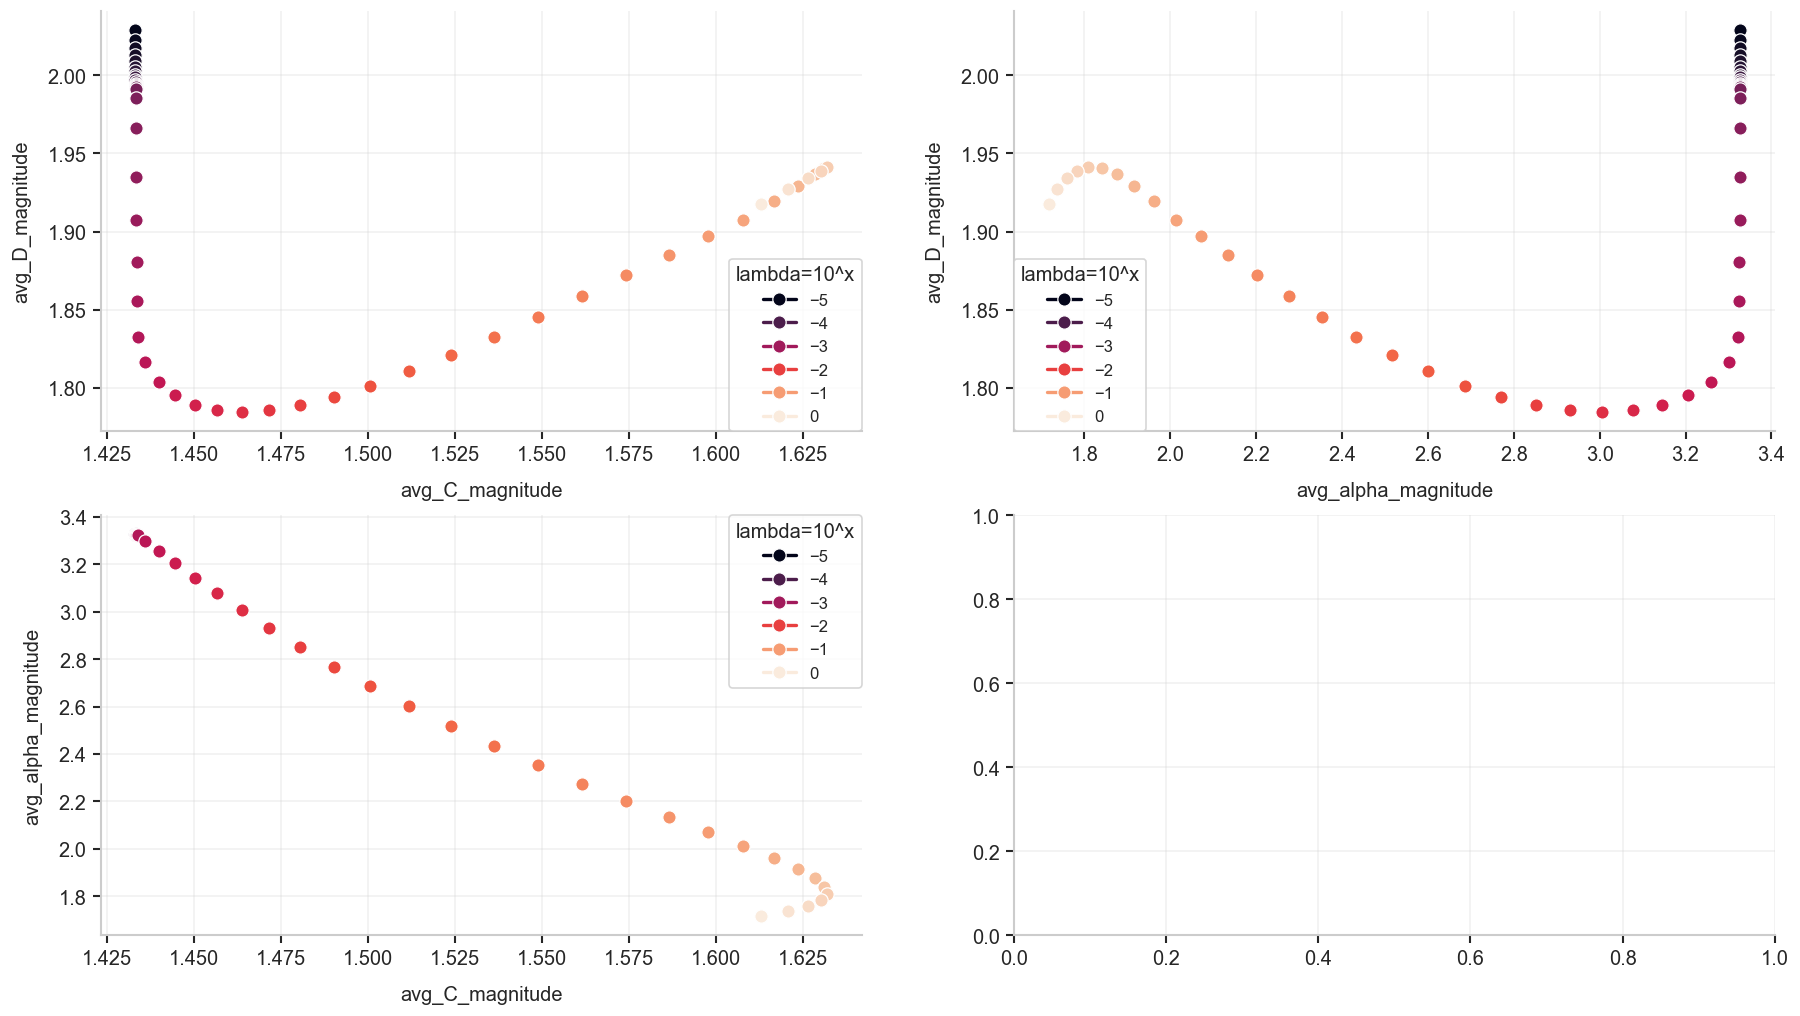

In [78]:
data = pd.DataFrame({'regularizer_exp': exps, 'avg_C_magnitude': cap_norms, 'avg_D_magnitude': diff_norms, 'avg_alpha_magnitude': alpha_norms})
# data = pd.melt(data, ['avg_C_magnitude', 'avg_D_magnitude'])
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=False, sharey=False) # sharex/sharey can be adjusted as needed
ax = sns.lineplot(data=data, x='avg_C_magnitude', y='avg_D_magnitude', hue='regularizer_exp', palette='rocket', marker='o', ax=axes[0, 0])
sns.move_legend(ax, loc='best', title='lambda=10^x')
ax = sns.lineplot(data=data, x='avg_C_magnitude', y='avg_alpha_magnitude', hue='regularizer_exp', palette='rocket', marker='o', ax=axes[1, 0])
sns.move_legend(ax, loc='best', title='lambda=10^x')
ax = sns.lineplot(data=data, x='avg_alpha_magnitude', y='avg_D_magnitude', hue='regularizer_exp', palette='rocket', marker='o', ax=axes[0, 1])
sns.move_legend(ax, loc='best', title='lambda=10^x')
plt.show()